<a href="https://colab.research.google.com/github/PalakMallik/handwritten-digits-identification/blob/main/handwritten_digits_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Handwritten Digits Identification**

# 1. Load libraries and frameworks

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets us build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models


In [ ]:
!unzip mnist-in-csv.zip

unzip:  cannot find or open mnist-in-csv.zip, mnist-in-csv.zip.zip or mnist-in-csv.zip.ZIP.


# 2. Load dataset

In [ ]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

In [ ]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

# 3. Pre-processing

# 3.1 Separate input and target

In [ ]:
# in teaining dataset
X_train = df.drop("label", axis = 1).values
y_train = df["label"].values

# in testing dataset
X_test = df_test.drop("label", axis = 1).values
y_test = df_test["label"].values

# 3.2 Feature scaling     (min-max normalizing pixel values)

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 3.3 Reshape (to 2-D array)

In [ ]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

# 3.4 One-hot encoding of target

In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
y_train_cat

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

# 4. Perceptron model

In [ ]:
perceptron = Sequential([
    Flatten(input_shape = (28, 28)),
    Dense(10, activation = "softmax")
])

In [ ]:
perceptron.compile(optimizer = "sgd", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
history_perceptron = perceptron.fit(X_train_img, y_train_cat, epochs = 5, batch_size = 32, validation_data = (X_test_img, y_test_cat), verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8140 - loss: 0.7830 - val_accuracy: 0.8800 - val_loss: 0.4818
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8799 - loss: 0.4583 - val_accuracy: 0.8938 - val_loss: 0.4015
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8906 - loss: 0.4048 - val_accuracy: 0.9007 - val_loss: 0.3679
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8963 - loss: 0.3783 - val_accuracy: 0.9054 - val_loss: 0.3496
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9002 - loss: 0.3614 - val_accuracy: 0.9088 - val_loss: 0.3365


# 5. Perceptron model evaluation

In [ ]:
acc_perceptron = perceptron.evaluate(X_test_img, y_test_cat, verbose = 0)[1]
print("Perceptron model accuracy : ", acc_perceptron)

Perceptron model accuracy :  0.9088000059127808


# 6. ANN model

In [ ]:
# Artificial Neural Network model

ann = Sequential([
    Flatten(input_shape = (28, 28)),
    Dense(128, activation = "relu"),
    Dense(64, activation = "relu"),
    Dense(10, activation = "softmax")
])

In [ ]:
ann.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs = 5, batch_size = 32, validation_data = (X_test_img, y_test_cat), verbose  =1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9298 - loss: 0.2397 - val_accuracy: 0.9650 - val_loss: 0.1195
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9692 - loss: 0.1009 - val_accuracy: 0.9688 - val_loss: 0.0991
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9788 - loss: 0.0695 - val_accuracy: 0.9710 - val_loss: 0.0947
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9828 - loss: 0.0547 - val_accuracy: 0.9731 - val_loss: 0.0863
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9859 - loss: 0.0418 - val_accuracy: 0.9771 - val_loss: 0.0820


# 7. ANN model evaluation

In [ ]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose = 0)[1]
print("ANN model accuracy :", acc_ann)

ANN model accuracy : 0.9771000146865845


# 8. CNN model

## Reshape

In [ ]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)    # This reshapes the flat/2D image arrays into the 4D format
X_test_cnn = X_test.reshape(-1, 28, 28, 1)   # that CNNs (specifically Conv2D layers in Keras/TensorFlow) expect

In [ ]:
cnn = Sequential([
    Conv2D(32, kernel_size = (3, 3), activation = "relu", input_shape = (28, 28, 1)),
    MaxPooling2D(pool_size = (2, 2)),
    Conv2D(64, kernel_size = (3, 3), activation = "relu"),
    MaxPooling2D(pool_size = (2, 2)),
    Flatten(),                   # converts the multi-dimensional feature maps coming out of the convolutional/pooling layers into a single 1D vector, so they can be fed into the Dense (fully-connected) layers
    Dense(128, activation = "relu"),
    Dropout(0.5),
    Dense(10, activation = "softmax")
])

In [ ]:
cnn.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs = 5, batch_size = 32, validation_data = (X_test_cnn, y_test_cat), verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9347 - loss: 0.2141 - val_accuracy: 0.9826 - val_loss: 0.0506
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9763 - loss: 0.0779 - val_accuracy: 0.9886 - val_loss: 0.0345
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9834 - loss: 0.0561 - val_accuracy: 0.9899 - val_loss: 0.0298
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9864 - loss: 0.0442 - val_accuracy: 0.9907 - val_loss: 0.0274
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9880 - loss: 0.0405 - val_accuracy: 0.9910 - val_loss: 0.0272


# 9. CNN model evaluation

In [ ]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose = 0)[1]
print("CNN model accuracy : ", acc_cnn)

CNN model accuracy :  0.9909999966621399


# 10. Plot accuracies and losses

In [34]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Validation")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Validation")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

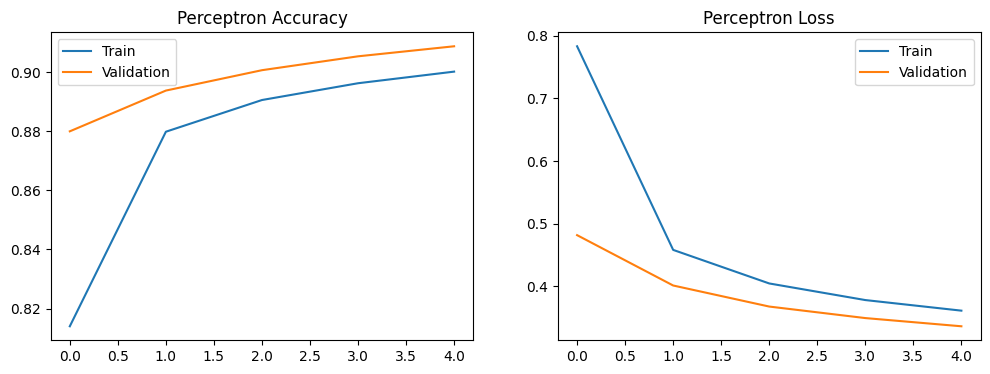

In [36]:
plot_training(history_perceptron, "Perceptron")

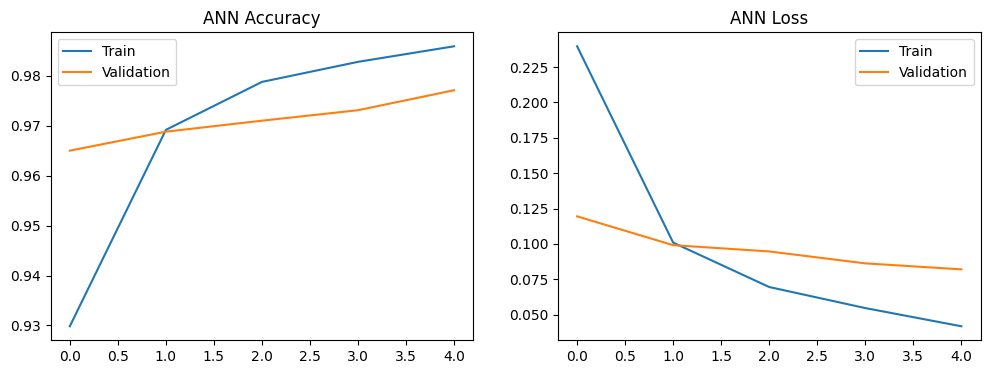

In [37]:
plot_training(history_ann, "ANN")

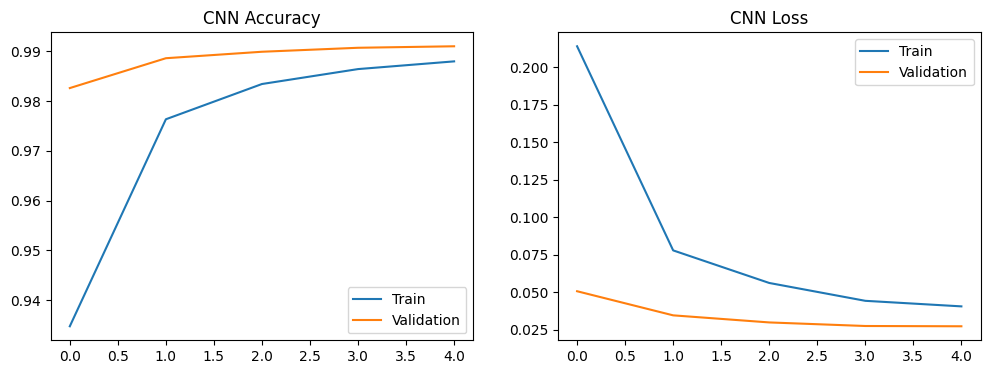

In [38]:
plot_training(history_cnn, "CNN")

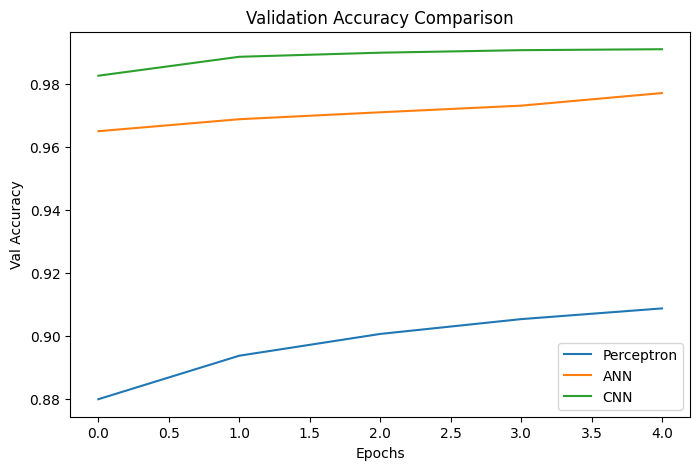

In [40]:
plt.figure(figsize=(8,5))
plt.plot(history_perceptron.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

# 11. Test perceptron, ANN and CNN models

In [41]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


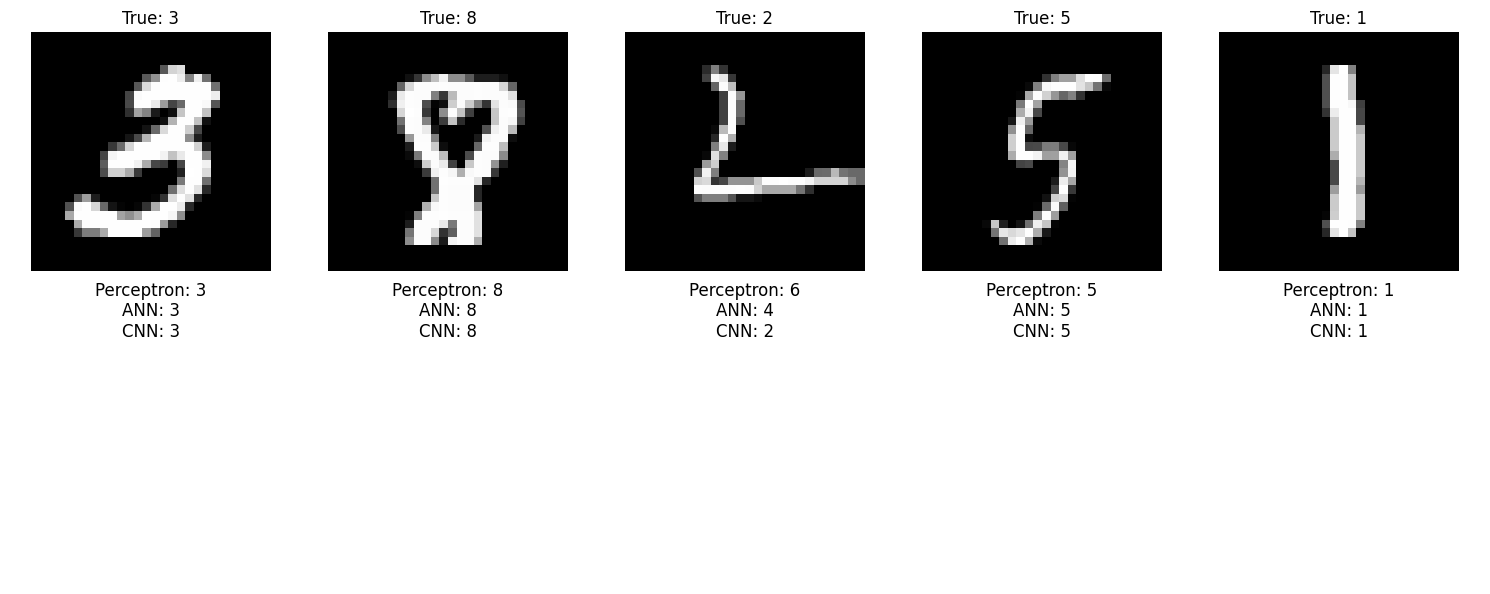

In [63]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

# 12. CNN confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


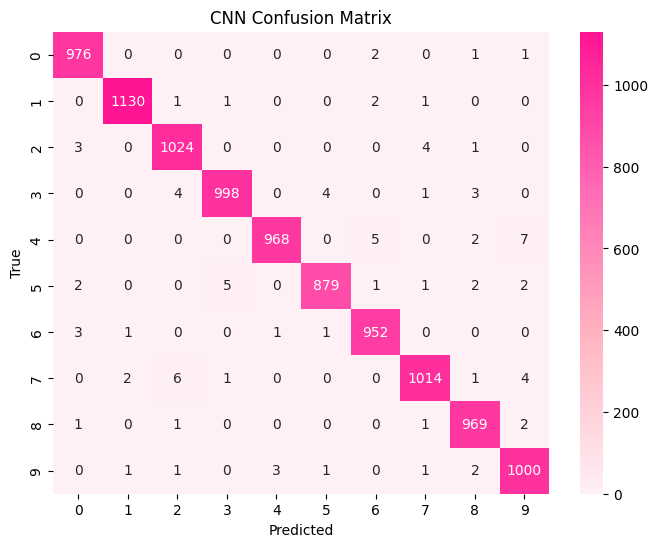

In [51]:
from matplotlib.colors import LinearSegmentedColormap

pink_cmap = LinearSegmentedColormap.from_list(
    "pink_cmap",
    ["#fff0f5", "#ffb6c1", "#ff69b4", "#ff1493"]
)

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap=pink_cmap)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 13. Perceptron vs ANN vs CNN

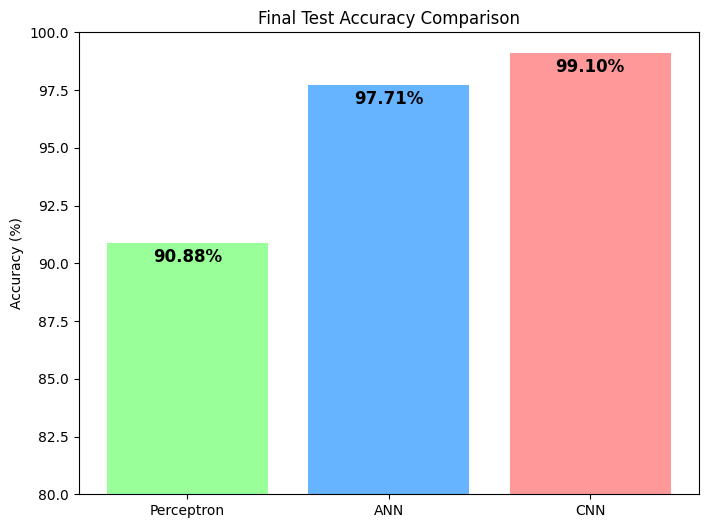

In [52]:
final_accs = [acc_perceptron*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#99ff99','#66b3ff','#ff9999'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()